# Выполнил

Неустроев Сергей, 409232

In [29]:
# @title Импорт бибилиотек

import math
import time
import tracemalloc
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable, List, Tuple, Union, Dict, Optional

# Класс комплексных чисел

In [30]:
class MyComplex:

    def __init__(self, real: float = 0.0, imag: float = 0.0) -> None:
        self.real = float(real)
        self.imag = float(imag)

    def __repr__(self) -> str:
        if self.imag >= 0:
            return f"({self.real}+{self.imag}j)"
        else:
            return f"({self.real}{self.imag}j)"

    @staticmethod
    def _to_complex(other):
        if isinstance(other, MyComplex):
            return other
        if isinstance(other, (int, float)):
            return MyComplex(other, 0.0)
        return NotImplemented

    def __add__(self, other) -> "MyComplex":
        other = self._to_complex(other)
        if other is NotImplemented:
            return NotImplemented
        return MyComplex(self.real + other.real, self.imag + other.imag)

    def __radd__(self, other) -> "MyComplex":
        return self + other

    def __sub__(self, other) -> "MyComplex":
        other = self._to_complex(other)
        if other is NotImplemented:
            return NotImplemented
        return MyComplex(self.real - other.real, self.imag - other.imag)

    def __rsub__(self, other) -> "MyComplex":
        other = self._to_complex(other)
        if other is NotImplemented:
            return NotImplemented
        return other - self

    def __mul__(self, other) -> "MyComplex":
        other = self._to_complex(other)
        if other is NotImplemented:
            return NotImplemented
        a, b = self.real, self.imag
        c, d = other.real, other.imag
        return MyComplex(a*c - b*d, a*d + b*c)

    def __rmul__(self, other) -> "MyComplex":
        return self * other

    def __truediv__(self, other) -> "MyComplex":
        other = self._to_complex(other)
        if other is NotImplemented:
            return NotImplemented
        a, b = self.real, self.imag
        c, d = other.real, other.imag
        denom = c*c + d*d
        if denom == 0:
            raise ZeroDivisionError("complex division by zero")
        return MyComplex((a*c + b*d) / denom, (b*c - a*d) / denom)

    def __rtruediv__(self, other) -> "MyComplex":
        other = self._to_complex(other)
        if other is NotImplemented:
            return NotImplemented
        return other / self

    def __neg__(self) -> "MyComplex":
        return MyComplex(-self.real, -self.imag)

    def conjugate(self) -> "MyComplex":
        return MyComplex(self.real, -self.imag)

    def __abs__(self) -> float:
        return math.hypot(self.real, self.imag)

    def __pow__(self, power: Union[int, float]) -> "MyComplex":
        if isinstance(power, int):
            if power == 0:
                return MyComplex(1.0, 0.0)
            if power < 0:
                return MyComplex(1.0, 0.0) / self.__pow__(-power)
            result = MyComplex(1.0, 0.0)
            base = self
            exp = power
            while exp > 0:
                if exp & 1:
                    result = result * base
                base = base * base
                exp >>= 1
            return result
        elif isinstance(power, (float, int)):
            r = abs(self)
            if r == 0:
                if power > 0:
                    return MyComplex(0.0, 0.0)
                elif power == 0:
                    return MyComplex(1.0, 0.0)
                else:
                    raise ZeroDivisionError("0 cannot be raised to a negative power")
            theta = math.atan2(self.imag, self.real)
            new_r = r ** power
            new_theta = power * theta
            return MyComplex(new_r * math.cos(new_theta), new_r * math.sin(new_theta))
        return NotImplemented

    def __eq__(self, other) -> bool:
        if isinstance(other, MyComplex):
            return self.real == other.real and self.imag == other.imag
        return NotImplemented

    def __hash__(self):
        return hash((self.real, self.imag))

# Реализованные функции

In [31]:
# @title Двумерная функция Розенброка

def rosenbrock_2d(x: float, y: float) -> float:
    return (1 - x) ** 2 + 100 * (y - x ** 2) ** 2

In [ ]:
# @title Многомерная функция Розенброка

def rosenbrock_nd(X: List[float]) -> float:
    total = 0.0
    for i in range(len(X) - 1):
        xi = X[i]
        x_next = X[i + 1]
        total += 100 * (x_next - xi ** 2) ** 2 + (1 - xi) ** 2
    return total

In [ ]:
# @title Градиент двухмерной функции Розенброка

def grad_rosenbrock_2d(x: float, y: float) -> Tuple[float, float]:
    dx = -2 * (1 - x) - 400 * x * (y - x ** 2)
    dy = 200 * (y - x ** 2)
    return dx, dy

In [ ]:
# @title Градиент двухмерной функции Розенброка

def grad_rosenbrock_nd(X: List[float]) -> List[float]:
    n = len(X)
    grad = [0.0] * n
    for i in range(n - 1):
        xi = X[i]
        x_next = X[i + 1]
        grad[i] += -2 * (1 - xi) - 400 * xi * (x_next - xi ** 2)
        grad[i + 1] += 200 * (x_next - xi ** 2)
    return grad

In [ ]:
# @title Функция, возвращающая значение и градиент

def rosenbrock_2d_with_grad(xy: np.ndarray) -> Tuple[float, np.ndarray]:
    x, y = xy[0], xy[1]
    f = (1 - x)**2 + 100 * (y - x**2)**2
    grad = np.array([-2*(1-x) - 400*x*(y - x**2), 200*(y - x**2)])
    return f, grad

In [ ]:
# @title Комплексная версия

def rosenbrock_2d_complex(xy: List[MyComplex]) -> MyComplex:
    return (1 - xy[0]) ** 2 + 100 * (xy[1] - xy[0] ** 2) ** 2

# Функции поиска минимума

In [ ]:
# @title Глобальные переменные для хранения данных
_gd_result = {}
_momentum_result = {}
_cs_result = {}

In [32]:
# @title Классический градиентный спуск

def gradient_descent(
    func: Callable[[np.ndarray], Tuple[float, np.ndarray]],
    x0: np.ndarray,
    lr: float = 1e-3,
    max_iter: int = 10000,
    tol_grad: float = 1e-6,
    tol_f: float = 1e-12,
    verbose: bool = False,
) -> dict:

    # func: функция, возвращающая (f, grad) для numpy-массива.

    x = x0.copy().astype(float)
    history_f = []
    history_grad_norm = []
    times = []
    grad_calls = 0

    tracemalloc.start()
    start_time = time.perf_counter()

    converged = False
    n_iter = 0
    final_f = None

    for t in range(1, max_iter + 1):
        f_val, grad = func(x)
        grad_calls += 1
        final_f = f_val
        history_f.append(f_val)
        grad_norm = np.linalg.norm(grad)
        history_grad_norm.append(grad_norm)
        times.append(time.perf_counter() - start_time)

        if grad_norm < tol_grad:
            n_iter = t
            converged = True
            break

        # Обновление
        x -= lr * grad

    if not converged:
        n_iter = max_iter

    exec_time = time.perf_counter() - start_time
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    peak_memory = peak

    k = max(1, len(history_f) // 10)
    f_prev = history_f[-k] if len(history_f) >= k else history_f[0]
    f_last = history_f[-1] if history_f else np.nan
    if f_prev != 0 and not np.isnan(f_last):
        relative_decrease = (f_prev - f_last) / f_prev
    else:
        relative_decrease = 0.0

    result = {
        'x_opt': x,
        'f_opt': final_f if final_f is not None else np.nan,
        'n_iter': n_iter,
        'converged': converged,
        'history_f': np.array(history_f),
        'history_grad': np.array(history_grad_norm),
        'times': np.array(times),
        'peak_memory_bytes': peak_memory,
        'true_minimum': 0.0,
        'execution_time': exec_time,
        'relative_decrease': relative_decrease,
        'distance_to_min': np.linalg.norm(x - np.zeros_like(x)),
        'total_func_calls': grad_calls,
        'integral_cost': grad_calls,
    }
    return result

In [ ]:
# @title Градиентный спуск с моментом

def gradient_descent_momentum(
    func: Callable[[np.ndarray], Tuple[float, np.ndarray]],
    x0: np.ndarray,
    lr: float = 1e-3,
    momentum: float = 0.9,
    max_iter: int = 10000,
    tol_grad: float = 1e-6,
    tol_f: float = 1e-12,
    verbose: bool = False,
) -> dict:

    x = x0.copy().astype(float)
    velocity = np.zeros_like(x)
    history_f = []
    history_grad_norm = []
    times = []
    grad_calls = 0

    tracemalloc.start()
    start_time = time.perf_counter()

    converged = False
    n_iter = 0
    final_f = None

    for t in range(1, max_iter + 1):
        f_val, grad = func(x)
        grad_calls += 1
        final_f = f_val
        history_f.append(f_val)
        grad_norm = np.linalg.norm(grad)
        history_grad_norm.append(grad_norm)
        times.append(time.perf_counter() - start_time)

        if grad_norm < tol_grad:
            n_iter = t
            converged = True
            break

        # Обновление скорости и позиции
        velocity = momentum * velocity - lr * grad
        x += velocity

    if not converged:
        n_iter = max_iter

    exec_time = time.perf_counter() - start_time
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    peak_memory = peak

    k = max(1, len(history_f) // 10)
    f_prev = history_f[-k] if len(history_f) >= k else history_f[0]
    f_last = history_f[-1] if history_f else np.nan
    if f_prev != 0 and not np.isnan(f_last):
        relative_decrease = (f_prev - f_last) / f_prev
    else:
        relative_decrease = 0.0

    result = {
        'x_opt': x,
        'f_opt': final_f if final_f is not None else np.nan,
        'n_iter': n_iter,
        'converged': converged,
        'history_f': np.array(history_f),
        'history_grad': np.array(history_grad_norm),
        'times': np.array(times),
        'peak_memory_bytes': peak_memory,
        'true_minimum': 0.0,
        'execution_time': exec_time,
        'relative_decrease': relative_decrease,
        'distance_to_min': np.linalg.norm(x - np.zeros_like(x)),
        'total_func_calls': grad_calls,
        'integral_cost': grad_calls,
    }
    return result

In [ ]:
# @title Градиентный спуск с комплексным шагом

# Вычисляет градиент функции f_complex (принимающей список MyComplex) в действительной точке
def complex_step_gradient(f_complex: Callable, x: List[float], h: float = 1e-20) -> List[float]:
    n = len(x)
    grad = [0.0] * n
    Xc = [MyComplex(xi, 0.0) for xi in x]
    for i in range(n):
        Xc_pert = Xc.copy()
        Xc_pert[i] = MyComplex(x[i], h)
        f_val = f_complex(Xc_pert)
        grad[i] = f_val.imag / h
    return grad


#Градиентный спуск, где градиент вычисляется методом комплексного шага
def gradient_descent_complex_step(
    f_complex: Callable[[List[MyComplex]], MyComplex],
    x0: List[float],
    lr: float = 1e-3,
    max_iter: int = 10000,
    tol_grad: float = 1e-6,
    h: float = 1e-20,
    verbose: bool = False,
) -> dict:
    x = np.array(x0, dtype=float)
    # Функция для получения значения (действительная часть)
    def f_float(x_arr: np.ndarray) -> float:
        Xc = [MyComplex(xi, 0.0) for xi in x_arr]
        return f_complex(Xc).real

    history_f = []
    history_grad_norm = []
    times = []
    grad_calls = 0

    tracemalloc.start()
    start_time = time.perf_counter()

    converged = False
    n_iter = 0
    final_f = None

    for t in range(1, max_iter + 1):
        f_val = f_float(x)
        final_f = f_val
        history_f.append(f_val)

        # Вычисляем градиент комплексным шагом
        g = complex_step_gradient(f_complex, x.tolist(), h)
        grad_calls += 1
        grad_norm = np.linalg.norm(g)
        history_grad_norm.append(grad_norm)
        times.append(time.perf_counter() - start_time)

        if grad_norm < tol_grad:
            n_iter = t
            converged = True
            break

        # Обновление
        x -= lr * np.array(g)

    if not converged:
        n_iter = max_iter

    exec_time = time.perf_counter() - start_time
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    peak_memory = peak

    k = max(1, len(history_f) // 10)
    f_prev = history_f[-k] if len(history_f) >= k else history_f[0]
    f_last = history_f[-1] if history_f else np.nan
    if f_prev != 0 and not np.isnan(f_last):
        relative_decrease = (f_prev - f_last) / f_prev
    else:
        relative_decrease = 0.0

    result = {
        'x_opt': x,
        'f_opt': final_f if final_f is not None else np.nan,
        'n_iter': n_iter,
        'converged': converged,
        'history_f': np.array(history_f),
        'history_grad': np.array(history_grad_norm),
        'times': np.array(times),
        'peak_memory_bytes': peak_memory,
        'true_minimum': 0.0,
        'execution_time': exec_time,
        'relative_decrease': relative_decrease,
        'distance_to_min': np.linalg.norm(x - np.zeros_like(x)),
        'total_func_calls': grad_calls,
        'integral_cost': grad_calls,
    }
    return result

In [33]:
# @title Функции обёртки для вывода информации

def _print_info(res: dict, method_name: str) -> None:
    f_opt = res['f_opt']
    n_iter = res['n_iter']
    peak_mem = res['peak_memory_bytes']
    true_min = res['true_minimum']
    diff_sq = (f_opt - true_min) ** 2

    print("=" * 60)
    print(f"РЕЗУЛЬТАТЫ ОПТИМИЗАЦИИ МЕТОДОМ {method_name}")
    print("=" * 60)
    print(f"Число итераций до сходимости: {n_iter}")
    print(f"Найденное значение f(x): {f_opt:.12e}")
    print(f"Истинный минимум f*: {true_min}")
    print(f"Квадрат разности (f - f*)^2: {diff_sq:.12e}")
    print(f"Пиковое потребление памяти: {peak_mem / 1024:.2f} КБ ({peak_mem} байт)")
    print(f"Фактическое время выполнения: {res['execution_time']:.4f} сек")
    print(f"Относительное снижение на последних итерациях: {res['relative_decrease']:.6e}")
    print(f"Евклидово расстояние до минимума: {res['distance_to_min']:.6e}")
    print(f"Всего вычислений градиента: {res['total_func_calls']}")
    print(f"Интегральная оценка вычислительных затрат: {res['integral_cost']}")
    if res['converged']:
        print("Статус: сошёлся по градиентному критерию.")
    else:
        print("Статус: достигнуто максимальное число итераций или произошла расходимость.")
    print("=" * 60)


def _plot_convergence(res: dict) -> None:
    if len(res['history_f']) == 0:
        print("Нет данных для построения графиков.")
        return
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.semilogy(res['history_f'], linewidth=1.5, color='blue')
    plt.xlabel('Итерация')
    plt.ylabel('f(x) (лог. шкала)')
    plt.title('Сходимость функции по итерациям')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.semilogy(res['times'], res['history_f'], linewidth=1.5, color='green')
    plt.xlabel('Время (сек)')
    plt.ylabel('f(x) (лог. шкала)')
    plt.title('Сходимость функции по времени')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def gd_def(f: Callable = None) -> None:
    if f is None:
        f = rosenbrock_2d_with_grad
    x0 = np.array([-1.2, 1.0])
    result = gradient_descent(
        func=f,
        x0=x0,
        lr=1e-3,
        max_iter=50000,
        tol_grad=1e-8,
        verbose=False
    )
    global _gd_result
    _gd_result = result

def gd_info() -> None:
    if not _gd_result:
        print("Ошибка: сначала запустите gd_def().")
        return
    res = _gd_result
    _print_info(res, "ГРАДИЕНТНЫЙ СПУСК (АНАЛИТИЧЕСКИЙ ГРАДИЕНТ)")
    _plot_convergence(res)


def momentum_def(f: Callable = None) -> None:
    if f is None:
        f = rosenbrock_2d_with_grad
    x0 = np.array([-1.2, 1.0])
    result = gradient_descent_momentum(
        func=f,
        x0=x0,
        lr=1e-3,
        momentum=0.9,
        max_iter=50000,
        tol_grad=1e-8,
        verbose=False
    )
    global _momentum_result
    _momentum_result = result

def momentum_info() -> None:
    if not _momentum_result:
        print("Ошибка: сначала запустите momentum_def().")
        return
    res = _momentum_result
    _print_info(res, "ГРАДИЕНТНЫЙ СПУСК С МОМЕНТОМ")
    _plot_convergence(res)


def complex_step_def() -> None:
    x0 = [-1.2, 1.0]
    result = gradient_descent_complex_step(
        f_complex=rosenbrock_2d_complex,
        x0=x0,
        lr=1e-3,
        max_iter=50000,
        tol_grad=1e-8,
        h=1e-20,
        verbose=False
    )
    global _cs_result
    _cs_result = result

def complex_step_info() -> None:
    if not _cs_result:
        print("Ошибка: сначала запустите complex_step_def().")
        return
    res = _cs_result
    _print_info(res, "ГРАДИЕНТНЫЙ СПУСК (КОМПЛЕКСНЫЙ ШАГ)")
    _plot_convergence(res)

# Запуск тестов

In [35]:
# @title Составные комплексные числа

a = MyComplex(3, 4)
b = MyComplex(1, -2)
print("a =", a)
print("b =", b)
print("a + b =", a + b)
print("a - b =", a - b)
print("a * b =", a * b)
print("a / b =", a / b)
print("|a| =", abs(a))
print("a^2 =", a ** 2)
print("a^0.5 =", a ** 0.5)
print("сопряжённое a =", a.conjugate())

a = (3.0+4.0j)
b = (1.0-2.0j)
a + b = (4.0+2.0j)
a - b = (2.0+6.0j)
a * b = (11.0-2.0j)
a / b = (-1.0+2.0j)
|a| = 5.0
a^2 = (-7.0+24.0j)
a^0.5 = (2.0+1.0j)
сопряжённое a = (3.0-4.0j)


РЕЗУЛЬТАТЫ ОПТИМИЗАЦИИ МЕТОДОМ ГРАДИЕНТНЫЙ СПУСК (АНАЛИТИЧЕСКИЙ ГРАДИЕНТ)
Число итераций до сходимости: 43606
Найденное значение f(x): 1.251770312371e-16
Истинный минимум f*: 0.0
Квадрат разности (f - f*)^2: 1.566928914934e-32
Пиковое потребление памяти: 4093.15 КБ (4191386 байт)
Фактическое время выполнения: 1.9612 сек
Относительное снижение на последних итерациях: 9.692641e-01
Евклидово расстояние до минимума: 1.414214e+00
Всего вычислений градиента: 43606
Интегральная оценка вычислительных затрат: 43606
Статус: сошёлся по градиентному критерию.


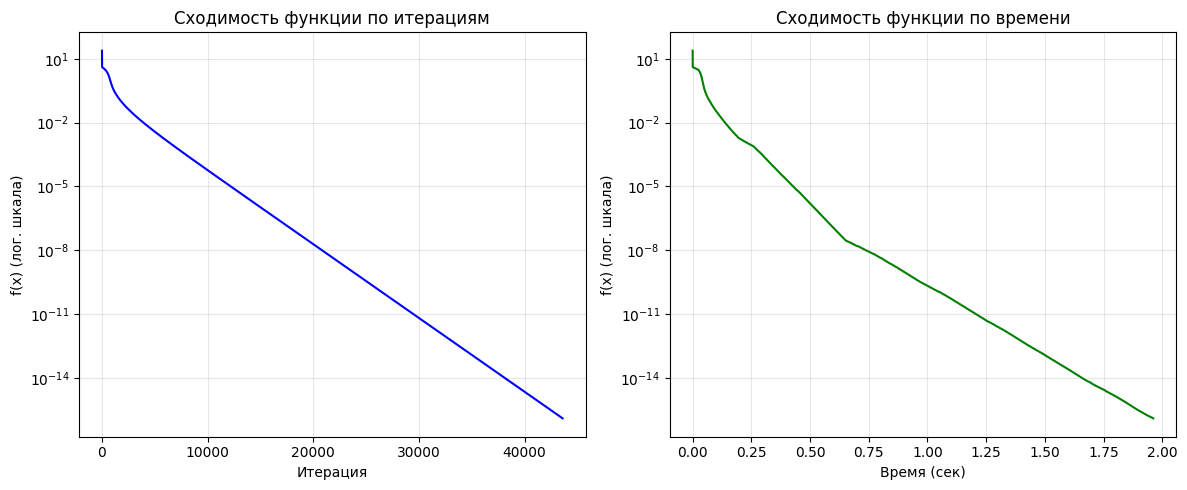

In [36]:
# @title Аналитический градиент

gd_def()
gd_info()

РЕЗУЛЬТАТЫ ОПТИМИЗАЦИИ МЕТОДОМ ГРАДИЕНТНЫЙ СПУСК С МОМЕНТОМ
Число итераций до сходимости: 4129
Найденное значение f(x): 1.243996115361e-16
Истинный минимум f*: 0.0
Квадрат разности (f - f*)^2: 1.547526335033e-32
Пиковое потребление памяти: 400.16 КБ (409764 байт)
Фактическое время выполнения: 0.1702 сек
Относительное снижение на последних итерациях: 9.672134e-01
Евклидово расстояние до минимума: 1.414214e+00
Всего вычислений градиента: 4129
Интегральная оценка вычислительных затрат: 4129
Статус: сошёлся по градиентному критерию.


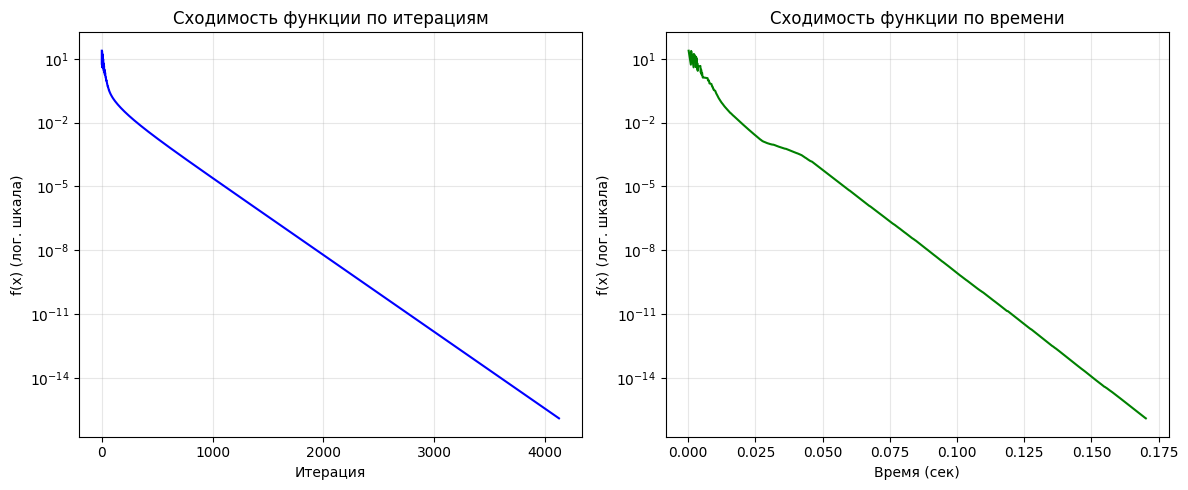

In [37]:
# @title Градиентный спуск с моментом

momentum_def()
momentum_info()

РЕЗУЛЬТАТЫ ОПТИМИЗАЦИИ МЕТОДОМ ГРАДИЕНТНЫЙ СПУСК (КОМПЛЕКСНЫЙ ШАГ)
Число итераций до сходимости: 43606
Найденное значение f(x): 1.251770312371e-16
Истинный минимум f*: 0.0
Квадрат разности (f - f*)^2: 1.566928914934e-32
Пиковое потребление памяти: 4096.48 КБ (4194793 байт)
Фактическое время выполнения: 8.2323 сек
Относительное снижение на последних итерациях: 9.692641e-01
Евклидово расстояние до минимума: 1.414214e+00
Всего вычислений градиента: 43606
Интегральная оценка вычислительных затрат: 43606
Статус: сошёлся по градиентному критерию.


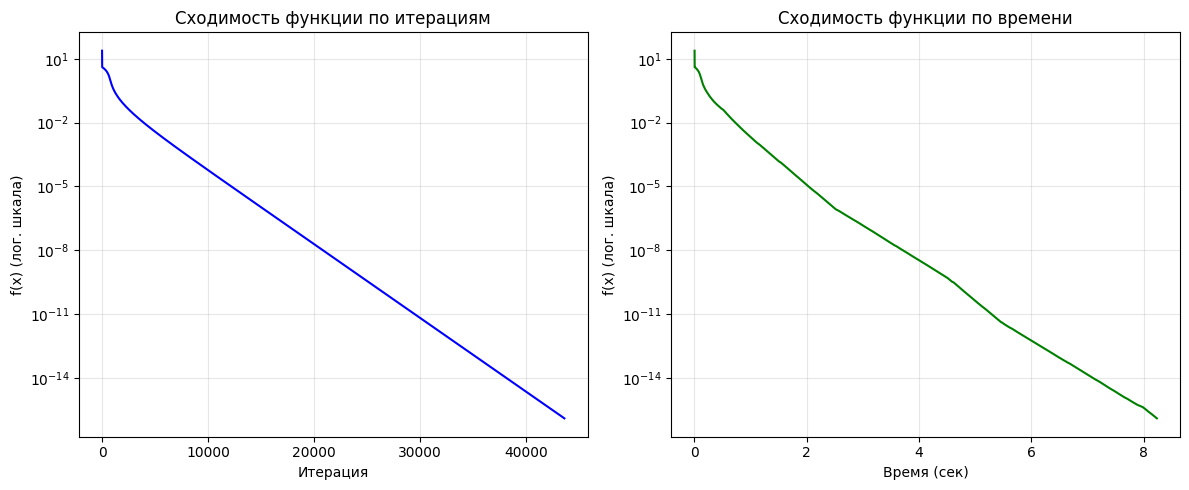

In [38]:
# @title Градиентный спуск с комплексным шагом

complex_step_def()
complex_step_info()
